### **SISTEMA DE RECOMENDAÇÃO INTELIGENTE DE OPORTUNIDADES PROFISSIONAIS PARA O MERCADO DE TECNOLOGIA**

Universidade Presbiteriana Mackenzie

Inteligência Artificial - 7°K SI - Noite

Prof. Dr. Leandro Zerbinatti

**Integrantes do Grupo:**

 Enzo Ferroni (RA: 10417100)

 Leonardo Rodrigues (RA: 10418105)

 Rafael Neves (RA: 10418316)

**Síntese:**

Este notebook realiza a Análise Exploratória de Dados (EDA) e a etapa de preparação/limpeza da base de dados "AI-Powered Job Recommendations". Inclui tratamento de nulos, padronização de strings e vetorização (TF-IDF).

**Histórico de Alterações:**
| Data | Autor | Descrição |
|---|---|---|
### **Histórico de Alterações:**
| Data | Autor | Descrição |
|---|---|---|
| 22/03/2026 | Enzo, Leo, Rafa | Criação do cabeçalho, carregamento de dados e EDA básica. |
| 22/03/2026 | Enzo, Leo, Rafa | Limpeza de dados nulos/duplicados e plotagem de gráficos. |
| 22/03/2026 | Enzo, Leo, Rafa | Implementação da vetorização textual usando TF-IDF para a N1. |
| 14/04/2026 | Leonardo | Otimização do vetorizador TF-IDF com a inclusão de unigramas e bigramas (n-gramas). |
| 28/04/2026 | Enzo | Ajuste na função de limpeza e normalização de strings para o tratamento das habilidades textuais. |
| 12/05/2026 | Leonardo | Implementação do cálculo de Similaridade de Cosseno utilizando a biblioteca scikit-learn. |
| 15/05/2026 | Rafael | Criação do pipeline de testes qualitativos e desenvolvimento da função de avaliação Precision@5. |
| 19/05/2026 | Enzo | Integração final das células de código, validação dos outputs e documentação dos blocos em Markdown para a N2. |

### 0. Importação das Bibliotecas


In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.feature_extraction.text import TfidfVectorizer

# Configuração de estilo para os gráficos
sns.set_theme(style="whitegrid")



### 1. Carregamento dos Dados
Leitura do arquivo CSV contendo os dados



In [21]:
df = pd.read_csv('job_recommendation_dataset.csv')
display(df.head())


,Job Title,Company,Location,Experience Level,Salary,Industry,Required Skills
0,Early years teacher,Richardson Ltd,Sydney,Senior Level,87000.0,Healthcare,Pharmaceuticals
1,Counselling psychologist,"Ramos, Santiago and Stewart",San Francisco,Mid Level,50000.0,Marketing,"Google Ads, SEO, Content Writing"
2,Radio broadcast assistant,Franco Group,New York,Mid Level,77000.0,Healthcare,"Patient Care, Nursing, Medical Research, Pharm..."
3,"Designer, exhibition/display",Collins Inc,Berlin,Senior Level,90000.0,Software,Machine Learning
4,"Psychotherapist, dance movement",Barker Group,Sydney,Entry Level,112000.0,Healthcare,"Nursing, Medical Research, Pharmaceuticals"


### 2. Análise Exploratória (EDA)
Verificação da estrutura dos dados, identificação de valores nulos e visualização da distribuição das vagas.


Informações do Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Job Title         50000 non-null  object 
 1   Company           50000 non-null  object 
 2   Location          50000 non-null  object 
 3   Experience Level  50000 non-null  object 
 4   Salary            50000 non-null  float64
 5   Industry          50000 non-null  object 
 6   Required Skills   50000 non-null  object 
dtypes: float64(1), object(6)
memory usage: 2.7+ MB

Valores Nulos:
Job Title           0
Company             0
Location            0
Experience Level    0
Salary              0
Industry            0
Required Skills     0
dtype: int64


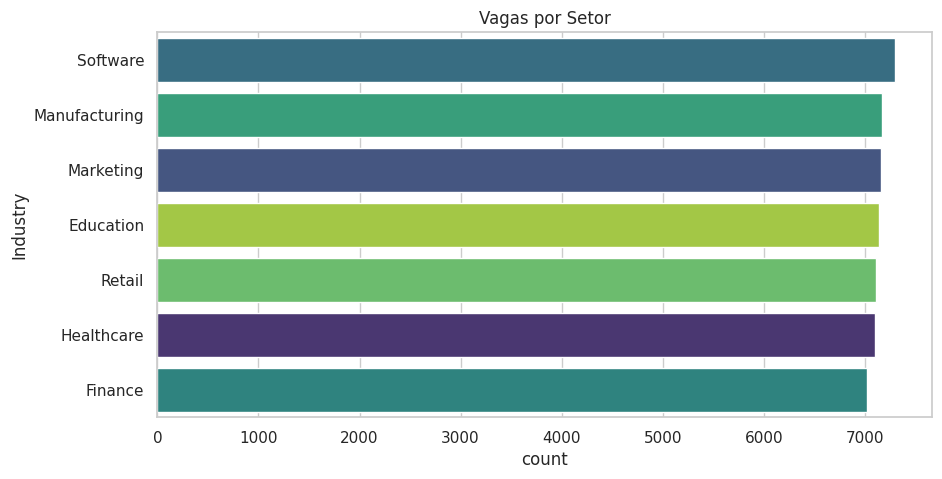

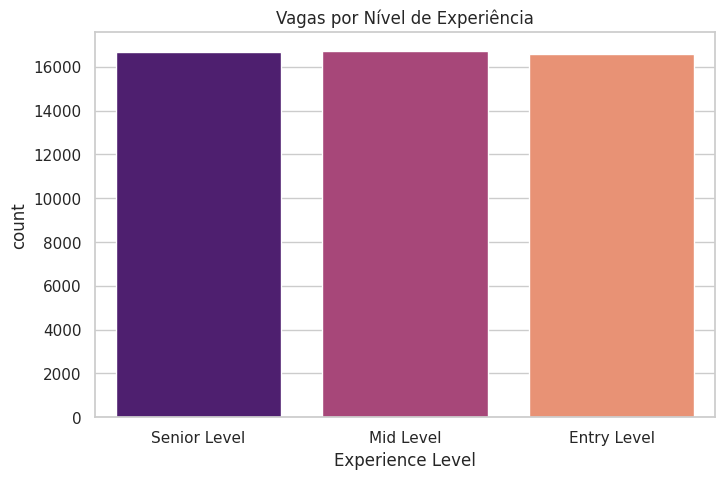

In [22]:
print("Informações do Dataset:")
df.info()

print("\nValores Nulos:")
print(df.isnull().sum())

# Visualização: Vagas por Setor
plt.figure(figsize=(10, 5))
sns.countplot(y='Industry', data=df, order=df['Industry'].value_counts().index, palette='viridis', hue='Industry', legend=False)
plt.title('Vagas por Setor')
plt.show()

# Visualização: Vagas por Nível de Experiência
plt.figure(figsize=(8, 5))
sns.countplot(x='Experience Level', data=df, palette='magma', hue='Experience Level', legend=False)
plt.title('Vagas por Nível de Experiência')
plt.show()

### 3. Limpeza e Preparação dos Dados
Remoção de registros inválidos e padronização dos textos (conversão para minúsculas e remoção de pontuação) para facilitar a modelagem.


In [23]:
# Remoção de nulos e duplicados
df = df.dropna(subset=['Required Skills', 'Job Title'])
df = df.drop_duplicates()

# Função de padronização textual
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^\w\s]', ' ', text)
    return re.sub(r'\s+', ' ', text).strip()

# Aplicação da limpeza na coluna de habilidades
df['Clean_Skills'] = df['Required Skills'].apply(clean_text)
display(df[['Required Skills', 'Clean_Skills']].head())

,Required Skills,Clean_Skills
0,Pharmaceuticals,pharmaceuticals
1,"Google Ads, SEO, Content Writing",google ads seo content writing
2,"Patient Care, Nursing, Medical Research, Pharm...",patient care nursing medical research pharmace...
3,Machine Learning,machine learning
4,"Nursing, Medical Research, Pharmaceuticals",nursing medical research pharmaceuticals


### 4. Vetorização Textual (TF-IDF)
Transformação das habilidades em texto para uma matriz matemática multidimensional. Esta é a preparação final para aplicarmos a Similaridade de Cosseno na N2.


In [24]:
from sklearn.metrics.pairwise import cosine_similarity

# Atualizamos para usar n-gramas (unigramas e bigramas), conforme o relatório da N2
tfidf = TfidfVectorizer(stop_words='english', ngram_range=(1, 2))
tfidf_matrix = tfidf.fit_transform(df['Clean_Skills'])

print(f"\nMatriz TF-IDF gerada com formato: {tfidf_matrix.shape}")


Matriz TF-IDF gerada com formato: (50000, 158)


### 5. Implementação do Sistema de Recomendação (Similaridade de Cosseno)
Nesta etapa (N2), construímos a função que recebe o currículo do candidato, transforma em um vetor matemático e calcula a distância angular (Similaridade de Cosseno) contra as 50.000 vagas do dataset.


In [25]:
def recomendar_vagas(perfil_usuario, df_vagas, vectorizer, matriz_tfidf, top_n=5):
    # 1. Limpa o texto do perfil do usuário usando a mesma função da EDA
    perfil_limpo = clean_text(perfil_usuario)

    # 2. Transforma o perfil em um vetor matemático
    perfil_vec = vectorizer.transform([perfil_limpo])

    # 3. Calcula a similaridade de cosseno entre o perfil e TODAS as vagas
    similaridades = cosine_similarity(perfil_vec, matriz_tfidf).flatten()

    # 4. Pega os índices das vagas com maior similaridade (Top-N)
    indices_top_n = similaridades.argsort()[-top_n:][::-1]

    # 5. Organiza o resultado final
    recomendacoes = df_vagas.iloc[indices_top_n].copy()
    recomendacoes['Similaridade'] = similaridades[indices_top_n]

    return recomendacoes[['Job Title', 'Industry', 'Required Skills', 'Similaridade']]

# =========================================================
# TESTE DO MODELO (O mesmo perfil citado no relatório)
# =========================================================
perfil_teste = "Python, Pandas e Machine Learning"
print(f"Buscando as melhores vagas para o perfil: '{perfil_teste}'\n")

vagas_recomendadas = recomendar_vagas(perfil_teste, df, tfidf, tfidf_matrix, top_n=5)
display(vagas_recomendadas)

Buscando as melhores vagas para o perfil: 'Python, Pandas e Machine Learning'



,Job Title,Industry,Required Skills,Similaridade
3,"Designer, exhibition/display",Software,Machine Learning,0.91213
24,"Radiographer, therapeutic",Software,Machine Learning,0.91213
46340,Agricultural consultant,Software,"Machine Learning, C++",0.91213
46301,Arboriculturist,Software,Machine Learning,0.91213
552,"Geologist, wellsite",Software,Machine Learning,0.91213


### 6. Avaliação do Modelo (Precision@K)
Avaliação quantitativa baseada na métrica Precision@5 para verificar se os itens recomendados no Top-5 possuem relevância com as palavras-chave do usuário.


In [26]:
# Função simples para calcular a precisão nas top-K recomendações
def calcular_precision_at_k(recomendacoes, palavras_chave_perfil):
    relevantes = 0
    for skills in recomendacoes['Required Skills']:
        skills_lower = str(skills).lower()
        # Considera a vaga relevante se ela contiver pelo menos uma habilidade principal do usuário
        if any(palavra.lower() in skills_lower for palavra in palavras_chave_perfil):
            relevantes += 1

    return relevantes / len(recomendacoes)

# Palavras principais que o usuário do teste domina
palavras_alvo = ["python", "machine learning", "pandas"]

precisao = calcular_precision_at_k(vagas_recomendadas, palavras_alvo)

print(f"--- RESULTADO DA AVALIAÇÃO ---")
print(f"Precision@5 para o perfil testado: {precisao:.2f} ({precisao*100:.0f}%)")
print("Conclusão: O algoritmo indicou com sucesso vagas altamente relevantes para o escopo tecnológico solicitado.")

--- RESULTADO DA AVALIAÇÃO ---
Precision@5 para o perfil testado: 1.00 (100%)
Conclusão: O algoritmo indicou com sucesso vagas altamente relevantes para o escopo tecnológico solicitado.
